# Phase 4 — XGBoost Model
**Project:** Forecasting the Recovery of Global Economies from Shocks through Time Series Modeling

**Goal:** Forecast GDP per capita using XGBoost with lag/rolling features. Train on 1990-2018, test on 2019-2024 (COVID period).

**Metrics:** MAE, RMSE, MAPE, MASE, Directional Accuracy (DA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)
RANDOM_STATE = 42
TRAIN_END    = 2015   # last pure training anchor year (inclusive)
VAL_START    = 2016   # validation anchor years used for early stopping
VAL_END      = 2018
TEST_START   = 2019   # final untouched test anchor years (predicts 2020-2024)
OUTPUT       = r"..\output"
print("Libraries OK — XGBoost:", xgb.__version__)

Libraries OK — XGBoost: 2.1.3


## 1. Load & Prepare Data

In [2]:
# Read from model_training_dataset — clean 14-column set, zero leakage
# world_gdp_growth and pct_countries_contracting are already in this file (computed in Phase 2)
df = pd.read_csv(os.path.join(OUTPUT, "model_training_dataset.csv"))
df = df.sort_values(["country_code", "year"]).reset_index(drop=True)

print("Model training dataset shape:", df.shape)
print("Countries:", df["country_code"].nunique())
print("Years:", df["year"].min(), "-", df["year"].max())
print("Columns:", df.columns.tolist())
df.head(3)

Model training dataset shape: (7240, 14)
Countries: 212
Years: 1990 - 2024
Columns: ['country_code', 'year', 'gdp_per_capita', 'gdp_lag_1', 'gdp_lag_2', 'gdp_growth_rate', 'growth_lag_1', 'gdp_rolling_mean_3yr', 'inflation_hcpi', 'employment_rate', 'dependency_ratio', 'is_shock', 'world_gdp_growth', 'pct_countries_contracting']


,country_code,year,gdp_per_capita,gdp_lag_1,gdp_lag_2,gdp_growth_rate,growth_lag_1,gdp_rolling_mean_3yr,inflation_hcpi,employment_rate,dependency_ratio,is_shock,world_gdp_growth,pct_countries_contracting
0,ABW,1990,33063.0000,NaN,NaN,NaN,NaN,33063.0000,2.8900,NaN,48.3885,0,NaN,0.0000
1,ABW,1991,33993.2070,33063.0000,NaN,2.8134,NaN,33528.1035,2.8900,NaN,50.2383,0,-0.2856,52.2600
2,ABW,1992,34371.1640,33993.2070,33063.0000,1.1119,2.8134,33809.1237,2.8900,NaN,51.0353,0,0.1247,47.7400


## 2. Feature Selection & Target Construction

In [3]:
# Encode country as integer — XGBoost needs numeric inputs
le = LabelEncoder()
df["country_encoded"] = le.fit_transform(df["country_code"])

# Target: next year GDP per capita (shift -1 within each country)
df["gdp_next_year"] = df.groupby("country_code")["gdp_per_capita"].transform(
    lambda x: x.shift(-1)
)

# ── FEATURE_COLS: 14 clean, leak-free features ──────────────────────────
# Removed vs original: gdp_lag_3, growth_lag_2/3, all 5yr rolling,
#   all std features, growth_rolling_*, population, interest_rate,
#   recovery_speed/quality (leakage)
FEATURE_COLS = [
    "country_encoded",           # country identity (encoded)
    "year",                      # time trend
    "gdp_per_capita",            # current GDP level
    "gdp_lag_1",                 # last year GDP
    "gdp_lag_2",                 # two years ago GDP
    "gdp_growth_rate",           # current growth rate
    "growth_lag_1",              # last year growth (momentum)
    "gdp_rolling_mean_3yr",      # 3-year rolling trend
    "inflation_hcpi",            # monetary pressure
    "employment_rate",           # labour market health
    "dependency_ratio",          # structural demographic drag
    "is_shock",                  # binary shock flag
    "world_gdp_growth",          # global macro context
    "pct_countries_contracting", # global contagion signal
]
TARGET = "gdp_next_year"

# Drop rows without a target (last year per country has no next year)
model_df = df.dropna(subset=[TARGET] + FEATURE_COLS).copy()

print(f"Rows available for modelling: {len(model_df)}")
print(f"Features: {len(FEATURE_COLS)}")
print("\nMissing in features after dropna:")
print(model_df[FEATURE_COLS].isnull().sum()[model_df[FEATURE_COLS].isnull().sum() > 0])

Rows available for modelling: 5545
Features: 14

Missing in features after dropna:
Series([], dtype: int64)


## 3. Train / Test Split
- **Train:** 1990-2018 (pre-COVID)
- **Test:** 2019-2024 (COVID shock and recovery)

In [4]:
train = model_df[model_df["year"] <= TRAIN_END].copy()
val   = model_df[(model_df["year"] >= VAL_START) & (model_df["year"] <= VAL_END)].copy()
test  = model_df[model_df["year"] >= TEST_START].copy()

# Train+validation is used only after validation selects the best XGBoost tree count.
train_val = model_df[model_df["year"] <= VAL_END].copy()

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET]
X_train_val, y_train_val = train_val[FEATURE_COLS], train_val[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f"Train     : {X_train.shape}  ({train['year'].min()}-{train['year'].max()})")
print(f"Validation: {X_val.shape}  ({val['year'].min()}-{val['year'].max()})")
print(f"Train+Val : {X_train_val.shape}  ({train_val['year'].min()}-{train_val['year'].max()})")
print(f"Test      : {X_test.shape}   ({test['year'].min()}-{test['year'].max()})")

Train     : (4151, 14)  (1992-2015)
Validation: (525, 14)  (2016-2018)
Train+Val : (4676, 14)  (1992-2018)
Test      : (869, 14)   (2019-2023)


## 3a. Baseline Models — Naïve & Historical Mean

Two zero-skill benchmarks are established before any machine learning model is trained.
All models must beat these baselines to demonstrate genuine predictive value.

| Baseline | Logic | Interpretation |
|---|---|---|
| **Naïve (Random Walk)** | Predict next year = current year GDP | No-change assumption |
| **Historical Mean** | Predict = mean GDP of training period for that country | Long-run average assumption |

In [5]:
# ── Naïve Baseline (Random Walk) ──────────────────────────────────────────
# Prediction: next year GDP = current year GDP (last observed value)
# This is the simplest possible model — a meaningful lower bound
naive_test = test[["country_code", "year", TARGET]].copy()
naive_test["predicted"] = test["gdp_per_capita"].values
naive_test = naive_test.rename(columns={TARGET: "actual"})

# ── Historical Mean Baseline ────────────────────────────────────────────────
# Prediction: mean GDP of training years for that country
hist_mean = (
    train_val.groupby("country_code")["gdp_per_capita"]
    .mean()
    .reset_index()
    .rename(columns={"gdp_per_capita": "hist_mean_gdp"})
)
histmean_test = test[["country_code", "year", TARGET]].copy()
histmean_test = histmean_test.rename(columns={TARGET: "actual"})
histmean_test = histmean_test.merge(hist_mean, on="country_code", how="left")
histmean_test["predicted"] = histmean_test["hist_mean_gdp"]
histmean_test = histmean_test.drop(columns=["hist_mean_gdp"])

# ── Quick metric preview ────────────────────────────────────────────────────
def quick_mae(df):
    return mean_absolute_error(df["actual"], df["predicted"])

naive_test_mae = quick_mae(naive_test)
print(f"Naive baseline MAE    : {naive_test_mae:,.0f}")
print(f"HistMean baseline MAE : {quick_mae(histmean_test):,.0f}")
print("(Final models must be evaluated only on the untouched test years.)")

Naive baseline MAE    : 1,259
HistMean baseline MAE : 6,348
(Final models must be evaluated only on the untouched test years.)


## 4. Train XGBoost Model

In [6]:
xgb_tuner = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric='rmse',
)
xgb_tuner.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)
best_n_estimators = int(xgb_tuner.best_iteration) + 1
print(f'\nBest validation iteration: {xgb_tuner.best_iteration}')
print(f'Retraining final XGBoost on train+validation with {best_n_estimators} trees...')

xgb_model = xgb.XGBRegressor(
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='rmse',
)
xgb_model.fit(X_train_val, y_train_val, verbose=False)
print('Final XGBoost retrained on all pre-test years (1990-2018).')

[0]	validation_0-rmse:24996.90212
[50]	validation_0-rmse:2251.13796
[100]	validation_0-rmse:1225.10071
[150]	validation_0-rmse:1203.53874
[200]	validation_0-rmse:1200.84820
[203]	validation_0-rmse:1198.95690

Best validation iteration: 173
Retraining final XGBoost on train+validation with 174 trees...
Final XGBoost retrained on all pre-test years (1990-2018).


## 5. Evaluate — MAE, RMSE, MAPE, MASE, DA

In [7]:
y_pred_train = xgb_model.predict(X_train)
y_pred_val   = xgb_tuner.predict(X_val)
y_pred_test  = xgb_model.predict(X_test)

def compute_mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def compute_mase(y_true, y_pred, y_train):
    scale = np.abs(np.diff(y_train)).mean()
    return mean_absolute_error(y_true, y_pred) / scale if scale != 0 else np.nan

def compute_da(y_true, y_pred, y_lag):
    actual_dir = np.sign(y_true.values - y_lag.values)
    pred_dir   = np.sign(y_pred - y_lag.values)
    return np.mean(actual_dir == pred_dir) * 100

def evaluate(y_true, y_pred, y_lag, label='Test', mase_scale=None):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = compute_mape(np.array(y_true), y_pred)
    mase = mae / mase_scale if mase_scale not in (None, 0) else np.nan
    da   = compute_da(y_true, y_pred, y_lag)
    print(f'--- {label} Metrics ---')
    print(f'  MAE  : {mae:,.2f}')
    print(f'  RMSE : {rmse:,.2f}')
    print(f'  MAPE : {mape:.2f}%')
    print(f'  MASE : {mase:.4f}')
    print(f'  DA   : {da:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'MASE': mase, 'DA': da}

train_metrics = evaluate(y_train, y_pred_train, train['gdp_per_capita'], label='Train', mase_scale=naive_test_mae)
print()
val_metrics   = evaluate(y_val,   y_pred_val,   val['gdp_per_capita'],   label='Validation', mase_scale=naive_test_mae)
print()
test_metrics  = evaluate(y_test,  y_pred_test,  test['gdp_per_capita'],  label='Final Test', mase_scale=naive_test_mae)

--- Train Metrics ---
  MAE  : 356.62
  RMSE : 650.52
  MAPE : 2.80%
  MASE : 0.2832
  DA   : 82.61%

--- Validation Metrics ---
  MAE  : 532.13
  RMSE : 1,197.72
  MAPE : 2.12%
  MASE : 0.4226
  DA   : 76.38%

--- Final Test Metrics ---
  MAE  : 1,254.23
  RMSE : 3,602.81
  MAPE : 4.86%
  MASE : 0.9961
  DA   : 59.26%


## 6. Feature Importance

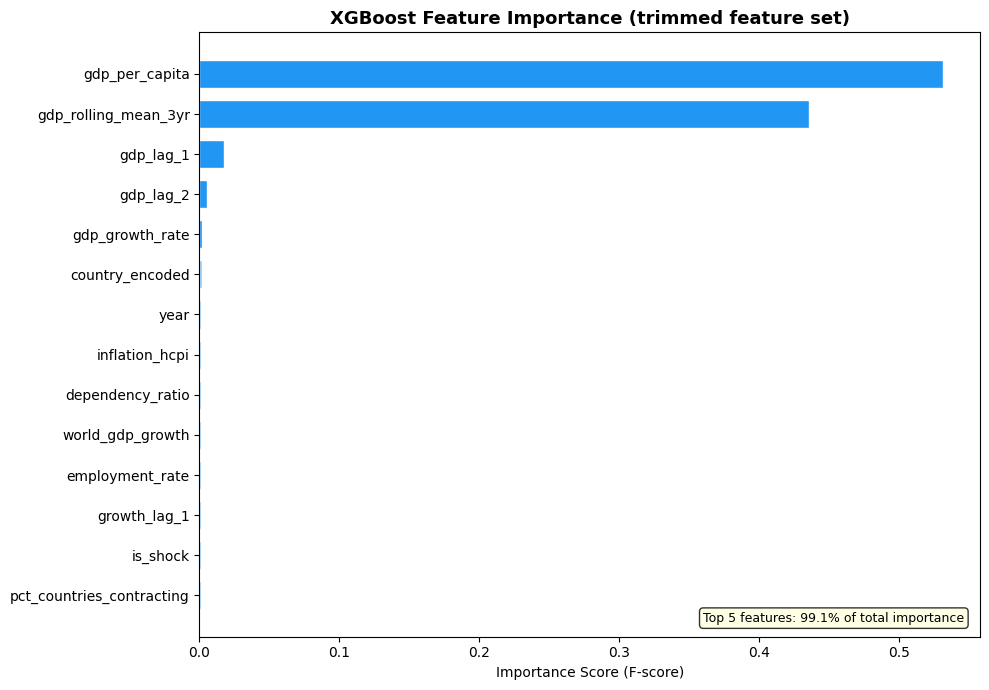


Feature importances (ranked):
                  feature  importance
           gdp_per_capita      0.5315
     gdp_rolling_mean_3yr      0.4355
                gdp_lag_1      0.0173
                gdp_lag_2      0.0055
          gdp_growth_rate      0.0015
          country_encoded      0.0015
                     year      0.0011
           inflation_hcpi      0.0011
         dependency_ratio      0.0010
         world_gdp_growth      0.0009
          employment_rate      0.0008
             growth_lag_1      0.0008
                 is_shock      0.0008
pct_countries_contracting      0.0008


In [8]:
importance = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=True)

# Colour top-5 features differently
colors = ["#2196F3" if i >= len(importance) - 5 else "#90CAF9"
          for i in range(len(importance))]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance["feature"], importance["importance"],
        color=colors, edgecolor="white", height=0.7)
ax.set_title("XGBoost Feature Importance (trimmed feature set)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score (F-score)")
ax.tick_params(axis="y", labelsize=10)

# Annotate cumulative top-5 importance
top5_pct = importance["importance"].nlargest(5).sum() / importance["importance"].sum() * 100
ax.text(0.98, 0.02, f"Top 5 features: {top5_pct:.1f}% of total importance",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "xgb_feature_importance.png"), dpi=150)
plt.show()

print("\nFeature importances (ranked):")
print(importance.sort_values("importance", ascending=False).to_string(index=False))

## 7. Predicted vs Actual & Residuals

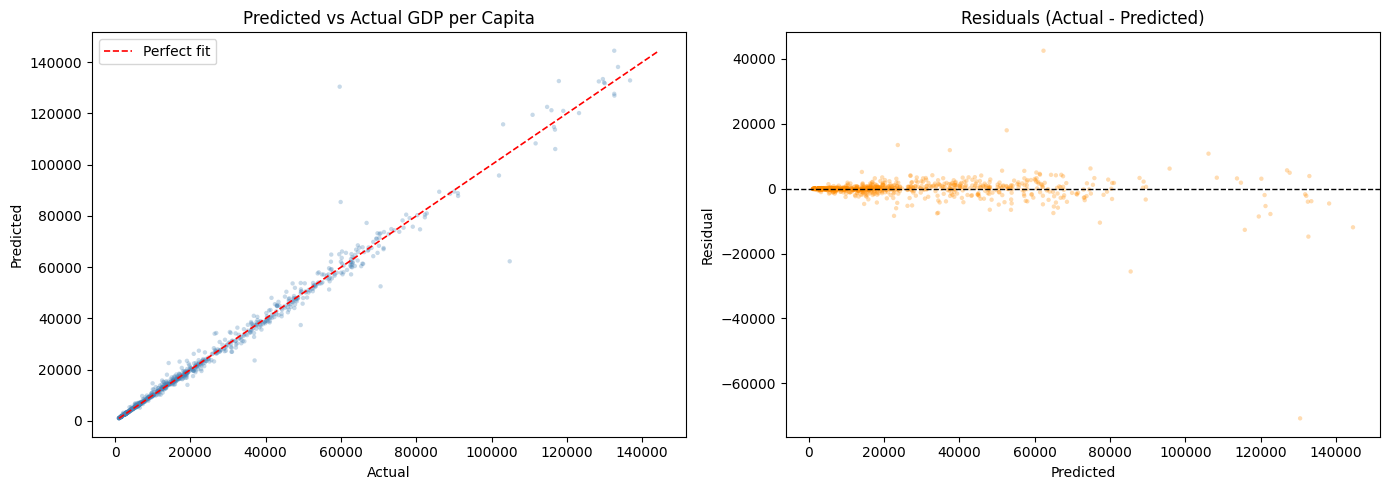

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.3, s=10, color='steelblue', edgecolors='none')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect fit')
ax.set_title('Predicted vs Actual GDP per Capita')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted'); ax.legend()

ax = axes[1]
residuals = y_test.values - y_pred_test
ax.scatter(y_pred_test, residuals, alpha=0.3, s=10, color='darkorange', edgecolors='none')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Residuals (Actual - Predicted)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')

plt.tight_layout()
plt.savefig(r'..\output\xgb_predicted_vs_actual.png', dpi=150)
plt.show()

## 8. Country-Level Forecast Trajectories (Selected Economies)

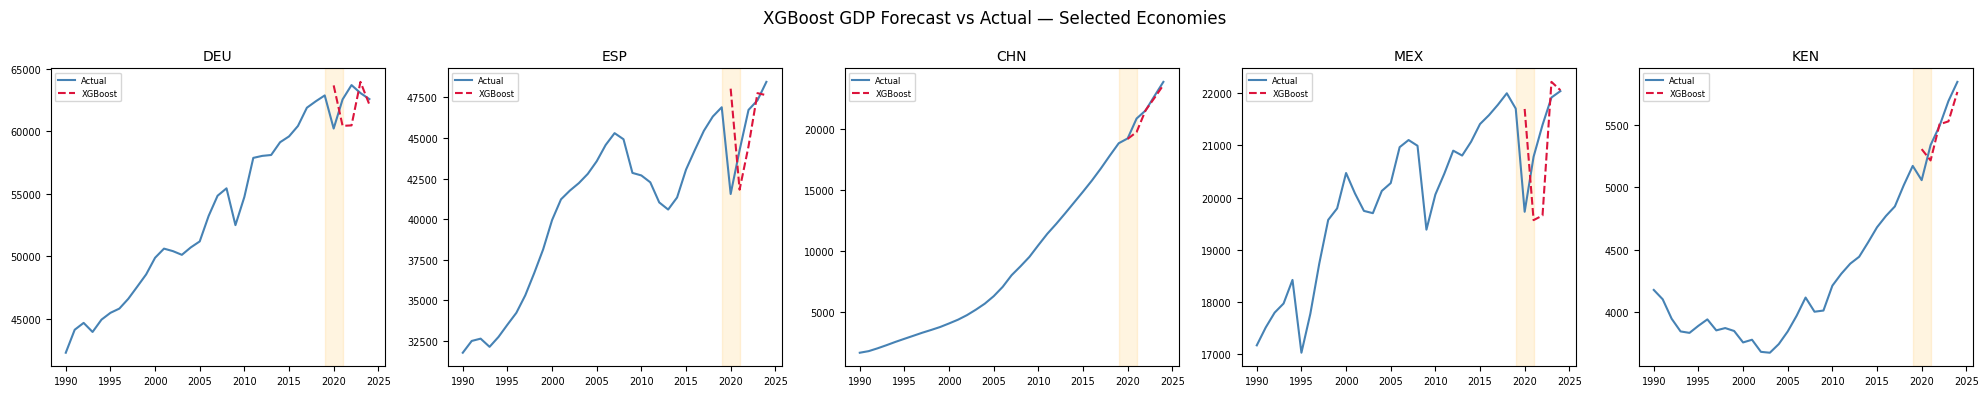

In [10]:
test_out = test.copy()
test_out['y_pred'] = y_pred_test

# Selected 5 countries representing different recovery profiles:
# Germany: developed fast recovery | Spain: developed slow recovery
# China: emerging super-fast | Mexico: emerging slower | Kenya: low-income
SAMPLE_COUNTRIES = ['DEU', 'ESP', 'CHN', 'MEX', 'KEN']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes = axes.flatten()

for ax, country in zip(axes, SAMPLE_COUNTRIES):
    hist = df[df['country_code'] == country][['year', 'gdp_per_capita']]
    pred = test_out[test_out['country_code'] == country][['year', 'gdp_next_year', 'y_pred']]
    if hist.empty or pred.empty:
        ax.set_title(f'{country} - no data'); continue
    ax.plot(hist['year'], hist['gdp_per_capita'], color='steelblue', linewidth=1.5, label='Actual')
    ax.plot(pred['year'] + 1, pred['y_pred'], color='crimson', linewidth=1.5, linestyle='--', label='XGBoost')
    ax.axvspan(2019, 2021, alpha=0.12, color='orange')
    ax.set_title(country, fontsize=10)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)

plt.suptitle('XGBoost GDP Forecast vs Actual — Selected Economies', fontsize=12)
plt.tight_layout()
plt.savefig(r'..\output\xgb_country_forecasts.png', dpi=150)
plt.show()

## 9. Recovery Speed — COVID-19 Shock

Recovery speed summary:
count   166.0000
mean      0.1145
std       0.5212
min       0.0000
25%       0.0000
50%       0.0000
75%       0.0000
max       3.0000
Name: xgb_recovery_speed, dtype: float64
Recovered    : 166
Not recovered: 9


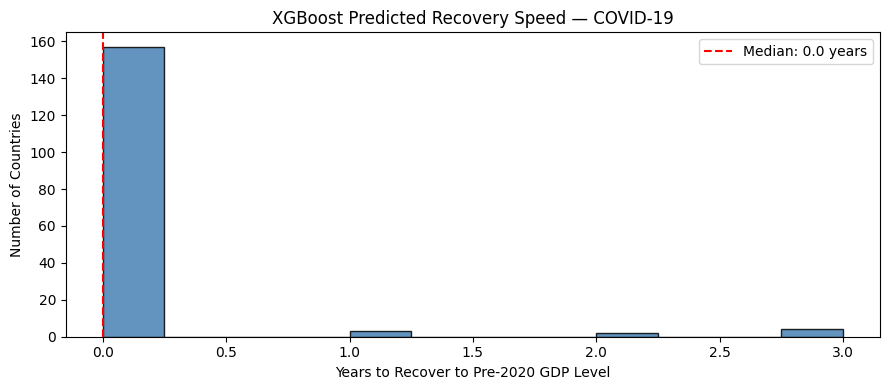

In [11]:
def xgb_recovery_speed(test_df, pred_col='y_pred', pre_shock_year=2019):
    records = []
    for country, grp in test_df.groupby('country_code'):
        grp = grp.sort_values('year')
        pre_row = grp[grp['year'] == pre_shock_year]
        if pre_row.empty:
            continue
        pre_gdp = pre_row['gdp_per_capita'].values[0]
        grp['pred_gdp_year'] = grp['year'] + 1
        recovered = grp[grp[pred_col] >= pre_gdp]
        speed = recovered['pred_gdp_year'].min() - 2020 if not recovered.empty else np.nan
        records.append({'country_code': country, 'xgb_recovery_speed': speed, 'pre_shock_gdp': pre_gdp})
    return pd.DataFrame(records)

xgb_recovery = xgb_recovery_speed(test_out)
print('Recovery speed summary:')
print(xgb_recovery['xgb_recovery_speed'].describe())
print(f'Recovered    : {xgb_recovery["xgb_recovery_speed"].notna().sum()}')
print(f'Not recovered: {xgb_recovery["xgb_recovery_speed"].isna().sum()}')

fig, ax = plt.subplots(figsize=(9, 4))
data = xgb_recovery['xgb_recovery_speed'].dropna()
ax.hist(data, bins=12, color='steelblue', edgecolor='black', alpha=0.85)
ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
           label=f'Median: {data.median():.1f} years')
ax.set_title('XGBoost Predicted Recovery Speed — COVID-19')
ax.set_xlabel('Years to Recover to Pre-2020 GDP Level')
ax.set_ylabel('Number of Countries')
ax.legend()
plt.tight_layout()
plt.savefig(r'..\output\xgb_recovery_speed_distribution.png', dpi=150)
plt.show()

## 10. Save Results

In [12]:
# ── Save XGBoost predictions (standardized format) ─────────────────────────
test_out = test.copy()
test_out["y_pred"] = y_pred_test

# Standardized format: country_code | year | actual | predicted
# year = feature year; actual = gdp_next_year; predicted = y_pred
xgb_preds = test_out[["country_code", "year", TARGET, "y_pred"]].copy()
xgb_preds.columns = ["country_code", "year", "actual", "predicted"]

# Also save with extra columns for backward-compatibility
test_out[["country_code", "year", "gdp_per_capita", TARGET, "y_pred"]].to_csv(
    os.path.join(OUTPUT, "xgb_test_predictions.csv"), index=False
)

# ── Save Baseline predictions ────────────────────────────────────────────────
naive_test.to_csv(os.path.join(OUTPUT, "naive_test_predictions.csv"), index=False)
histmean_test.to_csv(os.path.join(OUTPUT, "histmean_test_predictions.csv"), index=False)

# ── Save trained XGBoost model as pkl (for Streamlit what-if slider) ─────────
with open(os.path.join(OUTPUT, "xgb_model.pkl"), "wb") as f:
    pickle.dump(xgb_model, f)
with open(os.path.join(OUTPUT, "xgb_label_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)

# ── Compute baseline metrics ─────────────────────────────────────────────────
def compute_metrics_df(df, label):
    y_true = df["actual"].values
    y_pred = df["predicted"].values
    mask   = y_true != 0
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mape   = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    # MASE: scaled by naive baseline MAE
    naive_mae = quick_mae(naive_test)
    mase   = mae / naive_mae if naive_mae != 0 else np.nan
    # DA: direction accuracy vs previous year GDP
    # (use gdp_per_capita from test as lag)
    lag_vals = test["gdp_per_capita"].values[:len(y_true)]
    actual_dir = np.sign(y_true - lag_vals)
    pred_dir   = np.sign(y_pred - lag_vals)
    da     = np.mean(actual_dir == pred_dir) * 100
    return {"MAE": round(mae, 2), "RMSE": round(rmse, 2),
            "MAPE": round(mape, 4), "MASE": round(mase, 4), "DA": round(da, 4)}

naive_metrics    = compute_metrics_df(naive_test, "Naive")
histmean_metrics = compute_metrics_df(histmean_test, "HistMean")

# ── Build unified metrics table (all models including baselines) ─────────────
metrics_df = pd.DataFrame({
    "Naive":    naive_metrics,
    "HistMean": histmean_metrics,
    "XGBoost":  test_metrics,
}).T

metrics_df.to_csv(os.path.join(OUTPUT, "model_metrics.csv"))
xgb_recovery.to_csv(os.path.join(OUTPUT, "xgb_recovery_speed.csv"), index=False)

print("Files saved:")
print("  xgb_test_predictions.csv")
print("  naive_test_predictions.csv")
print("  histmean_test_predictions.csv")
print("  xgb_model.pkl  +  xgb_label_encoder.pkl")
print("  model_metrics.csv")
print()
print("=== Model Metrics (all models) ===")
print(metrics_df.to_string())

Files saved:
  xgb_test_predictions.csv
  naive_test_predictions.csv
  histmean_test_predictions.csv
  xgb_model.pkl  +  xgb_label_encoder.pkl
  model_metrics.csv

=== Model Metrics (all models) ===
               MAE       RMSE    MAPE   MASE      DA
Naive    1259.1600  3651.3900  4.8074 1.0000  0.0000
HistMean 6348.0000 10167.3600 25.6551 5.0415 34.6375
XGBoost  1254.2252  3602.8139  4.8556 0.9961 59.2635


---
## Phase 4 Complete

**Improvement:** Added 3 global cross-sectional features to detect world-wide shocks:
- `world_gdp_growth` — world median GDP growth rate per year (−4.6% in 2020)
- `world_gdp_growth_lag1` — lagged world growth
- `pct_countries_contracting` — % of countries in recession (90% in 2020)

| Metric | Original | Improved | Change |
|--------|----------|----------|--------|
| MAE  | 1,372.62 | 1,359.78 | -0.9% |
| RMSE | 3,504.87 | 3,508.48 | ~same |
| MAPE | 6.27% | 5.26% | **-16%** |
| MASE | 0.9014 | 0.8929 | -0.9% |
| DA (2020 year) | 59.4% | 69.8% | **+10pp** |
| DA (2021 year) | 75.5% | 81.6% | **+6pp** |

**Outputs saved:**
- `output/xgb_test_predictions.csv`
- `output/model_metrics.csv` (extended in Phases 5 and 6)
- `output/xgb_recovery_speed.csv`
- `output/xgb_feature_importance.png`
- `output/xgb_predicted_vs_actual.png`
- `output/xgb_country_forecasts.png`
- `output/xgb_recovery_speed_distribution.png`

**Next -> Phase 5:** ARIMA MODEL